In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.shape

(4000, 28)

In [4]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [6]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [8]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].unique())


 Farm_ID
<ArrowStringArray>
['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007',
 'SF10008', 'SF10009', 'SF10010',
 ...
 'SF13991', 'SF13992', 'SF13993', 'SF13994', 'SF13995', 'SF13996', 'SF13997',
 'SF13998', 'SF13999', 'SF14000']
Length: 4000, dtype: str

 State
<ArrowStringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

 District
<ArrowStringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str

 Crop
<ArrowStringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

 Season
<ArrowStringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

 Irrigation_Method
<ArrowStringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(4000, 28)

In [16]:
missing = df.isnull().sum()

missing[missing > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [17]:
missing_per = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": missing_per
})

missing_data[missing_data["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


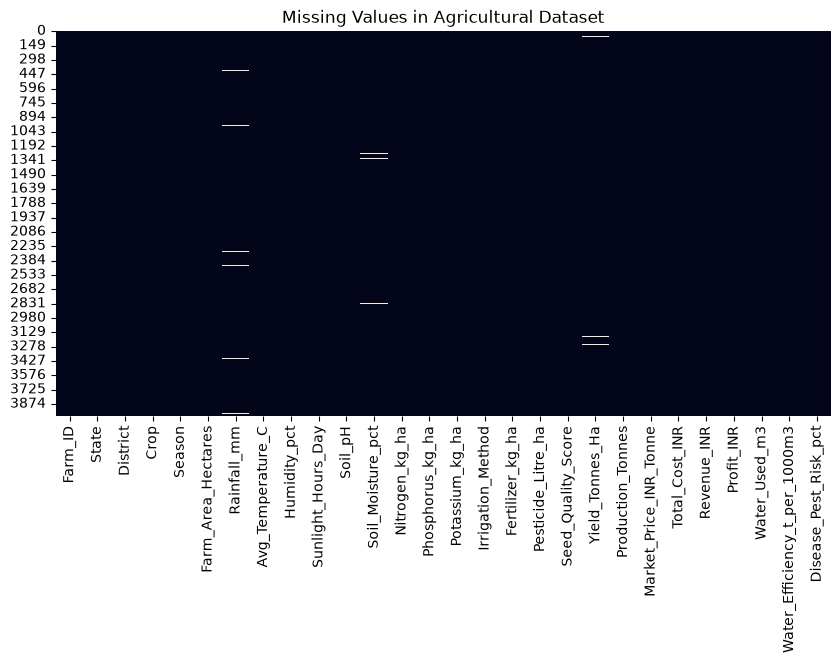

In [19]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Agricultural Dataset")
plt.show()

In [26]:
num_missing = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for col in num_missing:
    df[col] = df[col].fillna(df[col].median())

In [27]:
df.isnull().sum().sum()

np.int64(0)

In [28]:
df.dtypes

Farm_ID                               str
State                            category
District                         category
Crop                             category
Season                           category
Farm_Area_Hectares                float64
Rainfall_mm                       float64
Avg_Temperature_C                 float64
Humidity_pct                      float64
Sunlight_Hours_Day                float64
Soil_pH                           float64
Soil_Moisture_pct                 float64
Nitrogen_kg_ha                    float64
Phosphorus_kg_ha                  float64
Potassium_kg_ha                   float64
Irrigation_Method                category
Fertilizer_kg_ha                  float64
Pesticide_Litre_ha                float64
Seed_Quality_Score                float64
Yield_Tonnes_Ha                   float64
Production_Tonnes                 float64
Market_Price_INR_Tonne              int64
Total_Cost_INR                      int64
Revenue_INR                       

In [29]:
col_cat = [
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method"
]

for col in col_cat:
    df[col] = df[col].astype("category")

In [36]:
df["Profit_per_Hectare"] = (
    df["Profit_INR"] / df["Farm_Area_Hectares"]
)

In [38]:
df["Revenue_per_Hectare"] = (
    df["Revenue_INR"] / df["Farm_Area_Hectares"]
)

In [39]:
df["Cost_per_Hectare"] = (
    df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
)

In [40]:
df["Profit_Margin_pct"] = (
    df["Profit_INR"] / df["Revenue_INR"]
) * 100

In [41]:
df[
    [
        "Profit_per_Hectare",
        "Revenue_per_Hectare",
        "Cost_per_Hectare",
        "Profit_Margin_pct"
    ]
].head()

,Profit_per_Hectare,Revenue_per_Hectare,Cost_per_Hectare,Profit_Margin_pct
0,-22362.264151,58132.075472,80494.339623,-38.468030
1,-69211.332312,6186.983155,75398.315467,-1118.660429
2,-25667.489712,39190.534979,64858.024691,-65.494104
3,-21267.555556,44608.888889,65876.444444,-47.675600
4,-34287.885986,45987.410926,80275.296912,-74.559288


In [42]:
df["Farm_ID"].nunique()

4000

In [43]:
df["State"].nunique()

8

In [44]:
df["District"].nunique()

10

In [46]:
df["Crop"].nunique()

8

In [48]:
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [50]:
season = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,38.22


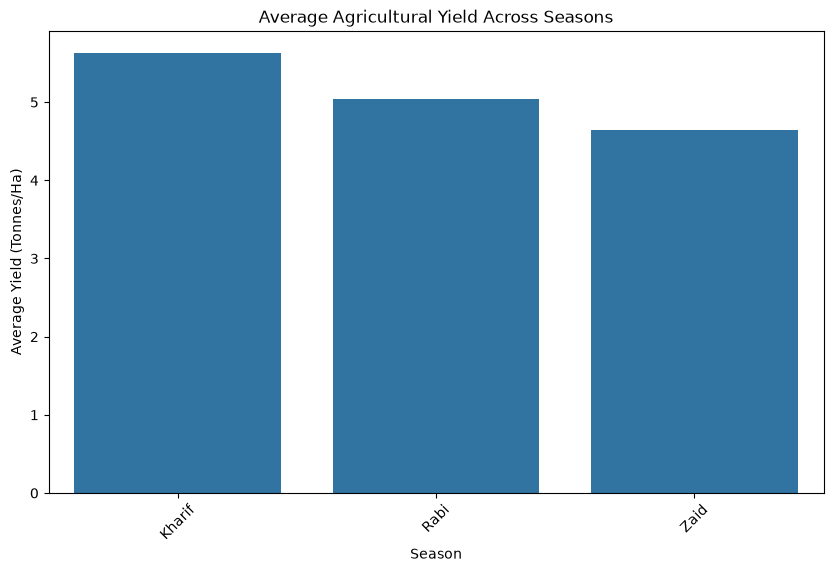

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Agricultural Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

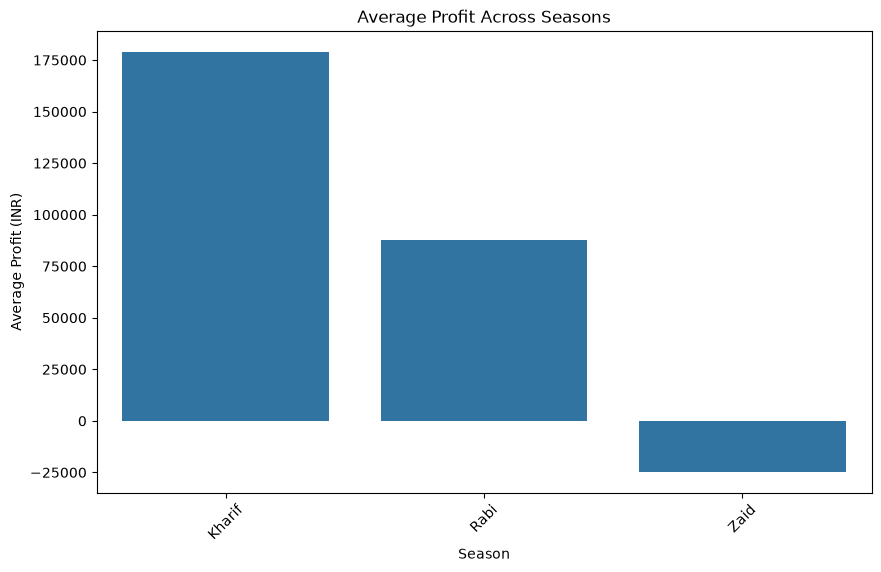

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar=None
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

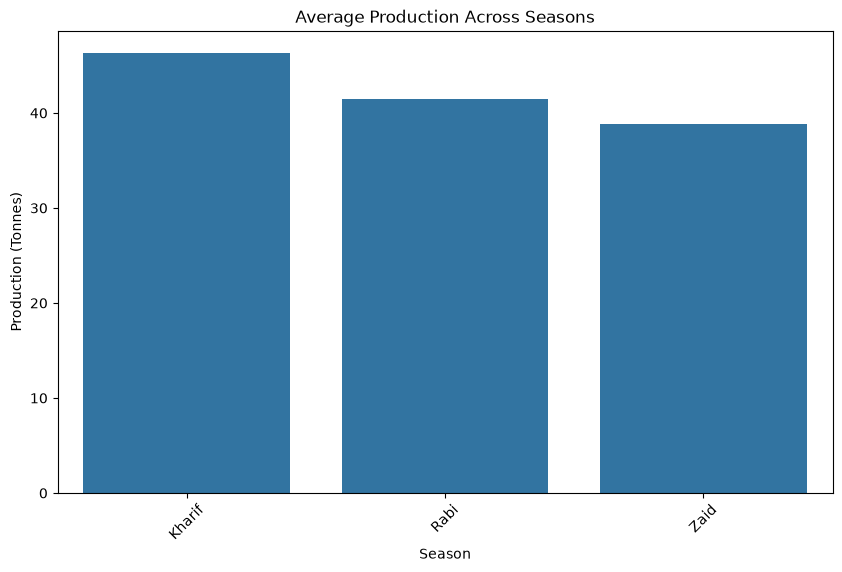

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Production_Tonnes",
    estimator="mean",
    errorbar=None
)

plt.title("Average Production Across Seasons")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.xticks(rotation=45)

plt.show()

In [58]:
s_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

s_yield

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64

In [59]:
s_yield.idxmax()

'Kharif'

In [60]:
s_yield.idxmin()

'Zaid'

In [62]:
s_profit = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

s_profit

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

In [63]:
s_profit.idxmax()

'Kharif'

In [65]:
resource = df.groupby("Season").agg({
    "Fertilizer_kg_ha": "mean",
    "Pesticide_Litre_ha": "mean",
    "Water_Used_m3": "mean",
    "Nitrogen_kg_ha": "mean",
    "Phosphorus_kg_ha": "mean",
    "Potassium_kg_ha": "mean"
}).round(2)

resource

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,187.08,5.08,6102.20,120.02,58.10,105.30
Rabi,185.41,5.02,5846.99,120.40,57.31,103.93
Zaid,184.64,5.17,6419.89,120.53,58.13,105.42


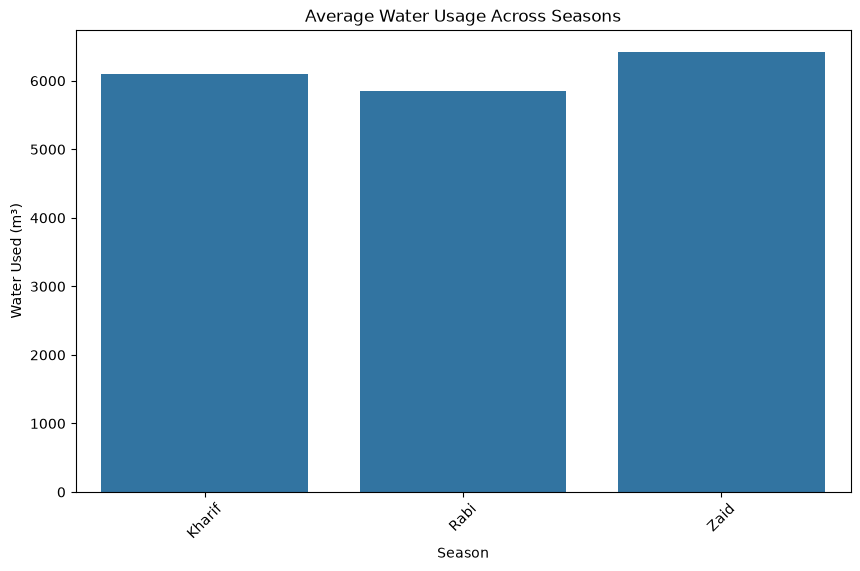

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    estimator="mean",
    errorbar=None
)

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=45)

plt.show()

In [70]:
irrigation_yield = (
    df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

irrigation_yield

Irrigation_Method
Drip         6.577989
Sprinkler    5.160627
Flood        4.863977
Rainfed      4.602142
Name: Yield_Tonnes_Ha, dtype: float64

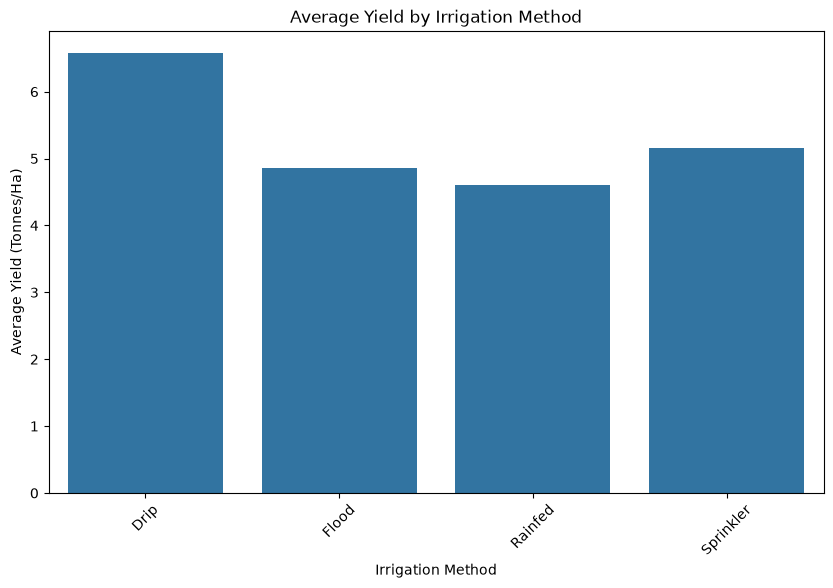

In [72]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

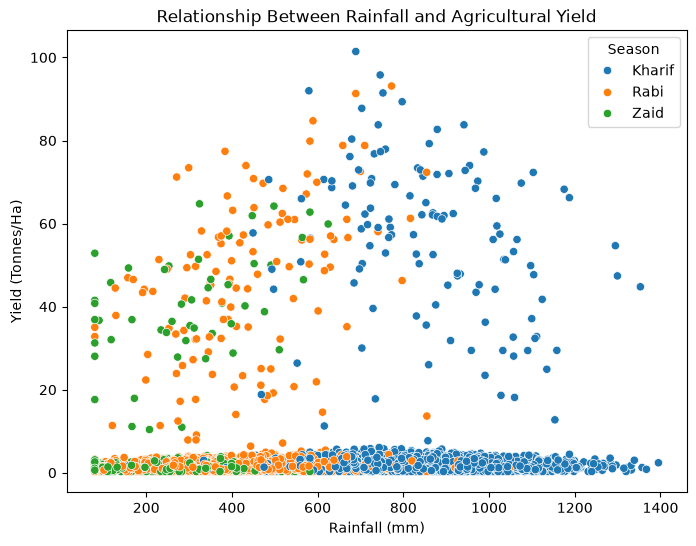

In [74]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Rainfall and Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [75]:
df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])

np.float64(0.030950993551650846)

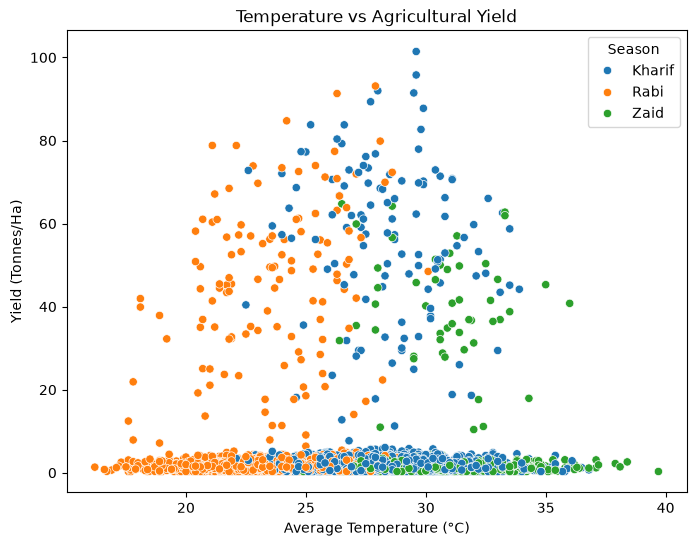

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature vs Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [82]:
df["Avg_Temperature_C"].corr(df["Yield_Tonnes_Ha"])

np.float64(0.009996320546703581)

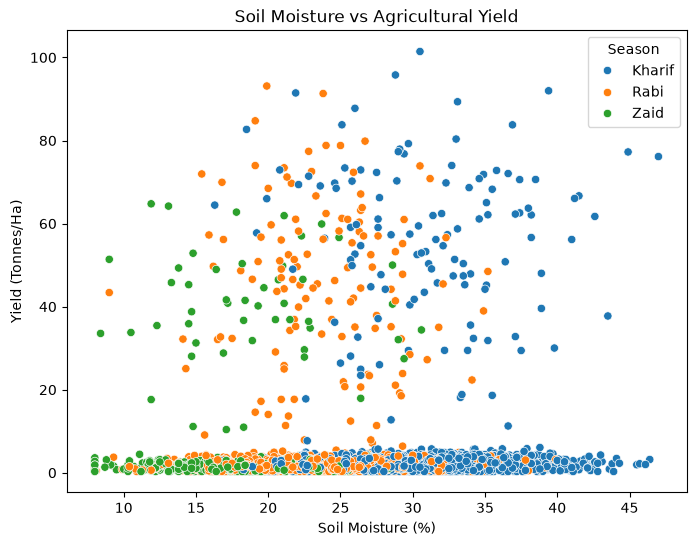

In [85]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Soil Moisture vs Agricultural Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [87]:
crop = df.groupby("Crop").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Revenue_INR": "mean"
}).sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)

crop

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR
Crop,,,,
Sugarcane,46.642361,392.413016,817187.986885,1.371980e+06
Maize,2.710036,21.781125,-83978.326679,4.570680e+05
Rice,2.431304,19.288623,-102213.504348,4.236153e+05
Wheat,2.108013,16.853909,-123398.337134,4.001049e+05
Chilli,1.542767,12.382888,750878.342233,1.276777e+06
Groundnut,1.322901,9.655825,44858.120283,5.429355e+05
Cotton,1.229783,9.395866,124546.915354,6.394231e+05
Pulses,0.921512,7.401411,-4238.052419,5.284659e+05


In [89]:
top_crops = (
    df.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_crops

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64

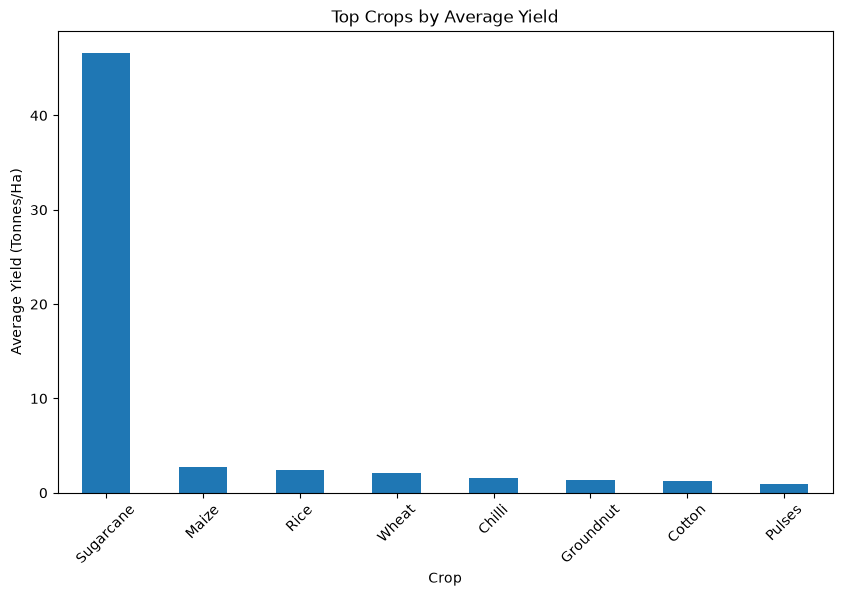

In [92]:
plt.figure(figsize=(10,6))

top_crops.plot(kind="bar")

plt.title("Top Crops by Average Yield")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

In [96]:
crop_season = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


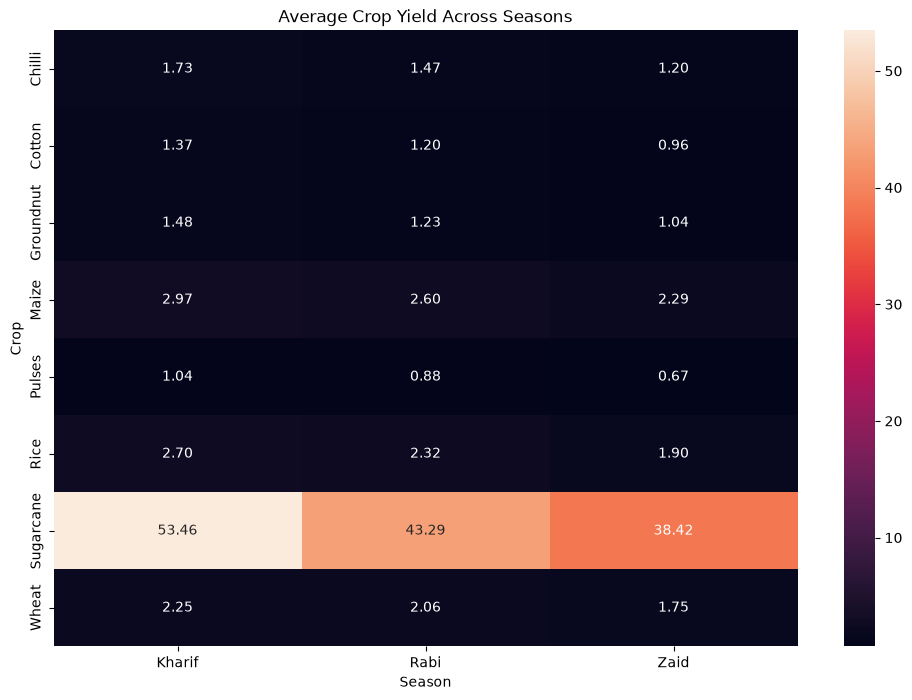

In [97]:
plt.figure(figsize=(12,8))

sns.heatmap(
    crop_season,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [100]:
state = df.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Revenue_INR": "mean"
}).sort_values(
    "Profit_INR",
    ascending=False
)

state

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR
State,,,,
Punjab,6.121116,52.233099,136025.636364,686225.702479
Maharashtra,5.017480,43.984043,135428.855469,650032.669922
Karnataka,5.685481,47.732720,119422.335378,653426.182004
Tamil Nadu,4.875175,40.840371,117744.748454,629093.416495
Gujarat,5.659016,48.331988,117568.235656,654692.860656
Telangana,5.044477,39.254186,108829.616279,628784.532946
Madhya Pradesh,4.989940,37.559517,86840.756539,597558.358149
Andhra Pradesh,4.628771,36.913157,73453.527410,606663.659735


In [102]:
state.head(10)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR
State,,,,
Punjab,6.121116,52.233099,136025.636364,686225.702479
Maharashtra,5.017480,43.984043,135428.855469,650032.669922
Karnataka,5.685481,47.732720,119422.335378,653426.182004
Tamil Nadu,4.875175,40.840371,117744.748454,629093.416495
Gujarat,5.659016,48.331988,117568.235656,654692.860656
Telangana,5.044477,39.254186,108829.616279,628784.532946
Madhya Pradesh,4.989940,37.559517,86840.756539,597558.358149
Andhra Pradesh,4.628771,36.913157,73453.527410,606663.659735


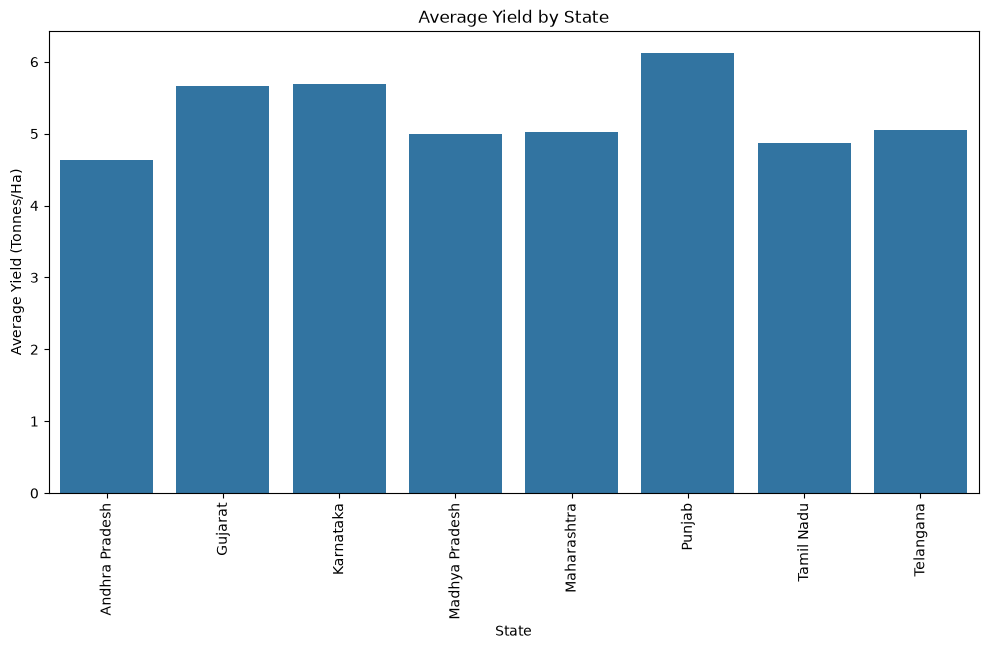

In [104]:
plt.figure(figsize=(12,6))

state_yield = (
    df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=state_yield.index,
    y=state_yield.values
)

plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=90)

plt.show()

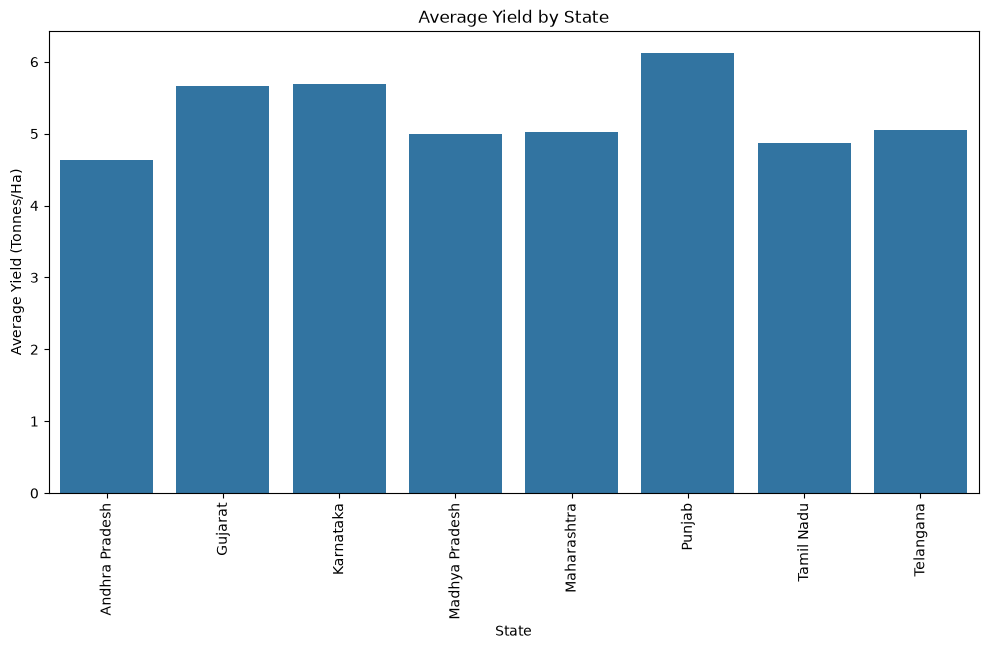

In [107]:
plt.figure(figsize=(12,6))

state_yield = (
    df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=state_yield.index,
    y=state_yield.values
)

plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=90)

plt.show()

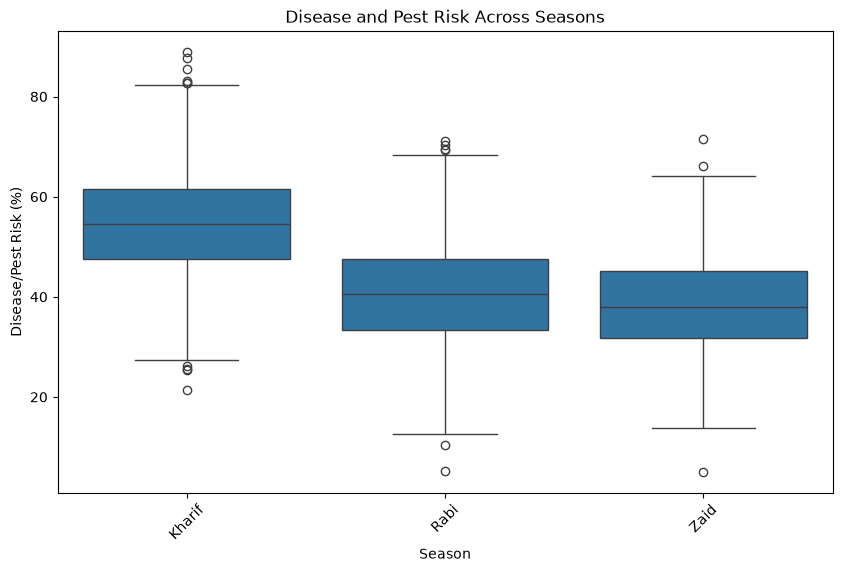

In [111]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct"
)

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.xticks(rotation=45)

plt.show()

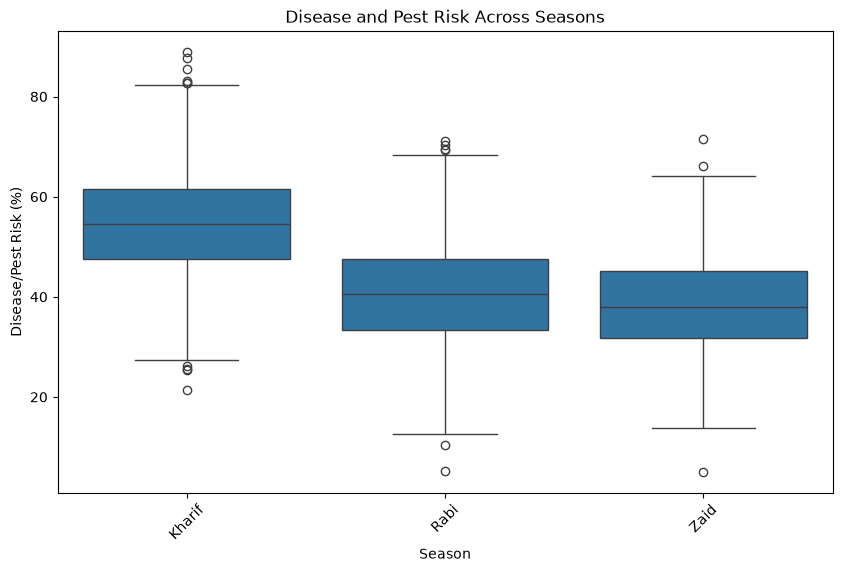

In [113]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct"
)

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.xticks(rotation=45)

plt.show()

In [115]:
water_eff = (
    df.groupby("Season")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

water_eff

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64

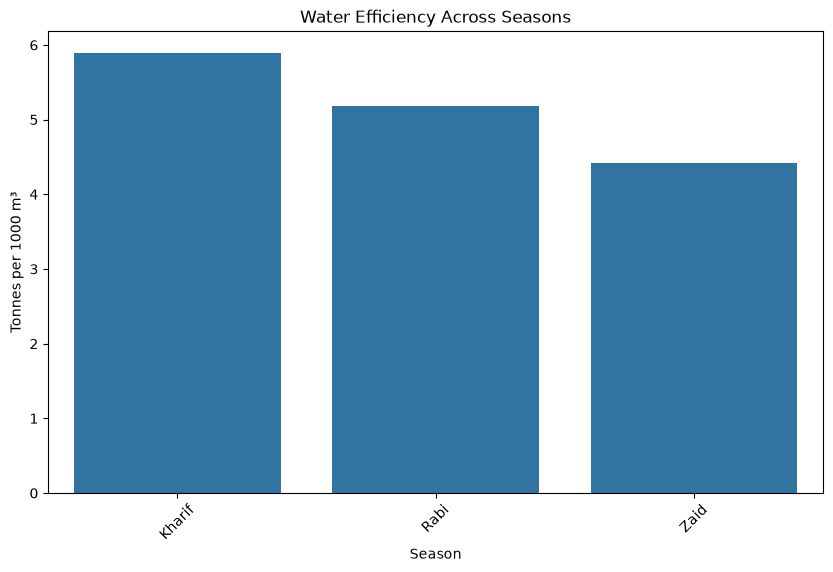

In [118]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None
)

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=45)

plt.show()

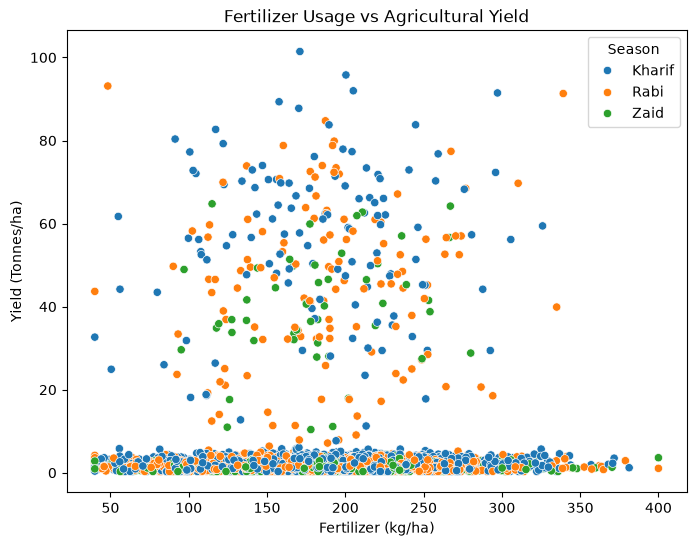

In [121]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Fertilizer Usage vs Agricultural Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/ha)")

plt.show()

In [123]:
df["Fertilizer_kg_ha"].corr(
    df["Yield_Tonnes_Ha"]
)

np.float64(1.7712703696051044e-05)

In [126]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[numeric_columns].corr()

correlation["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Revenue_per_Hectare              0.542074
Profit_per_Hectare               0.535367
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Profit_Margin_pct                0.204993
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Cost_per_Hectare                 0.003231
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0

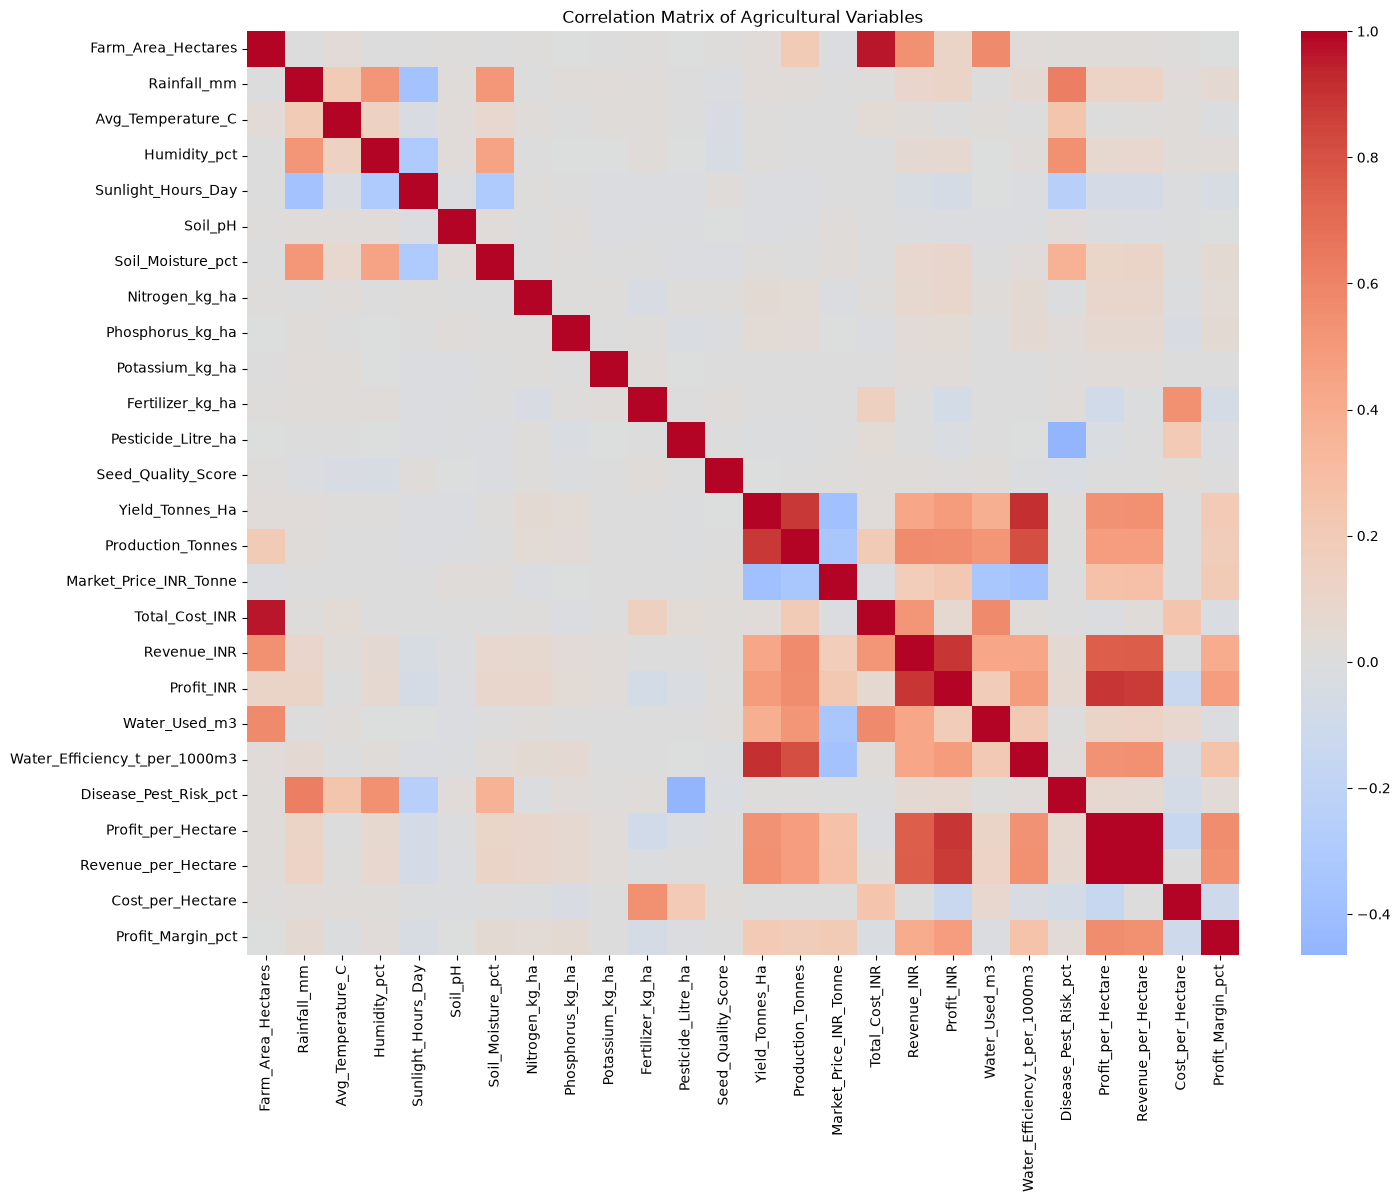

In [129]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

In [132]:
economic = df.groupby("Season").agg({
    "Market_Price_INR_Tonne": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Profit_Margin_pct": "mean"
}).round(2)

economic

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,
Kharif,44850.91,531804.41,710719.06,178914.65,-38.64
Rabi,44747.97,513836.58,601526.05,87689.47,-44.27
Zaid,44212.03,543976.73,519171.90,-24804.82,-69.35


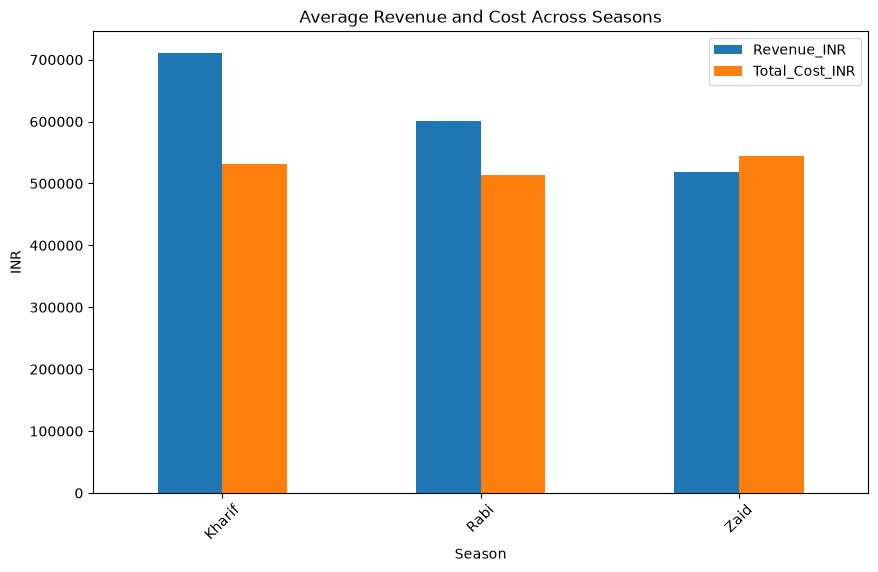

In [134]:
economic_plot = df.groupby("Season").agg({
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean"
})

economic_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Revenue and Cost Across Seasons")
plt.xlabel("Season")
plt.ylabel("INR")
plt.xticks(rotation=45)

plt.show()

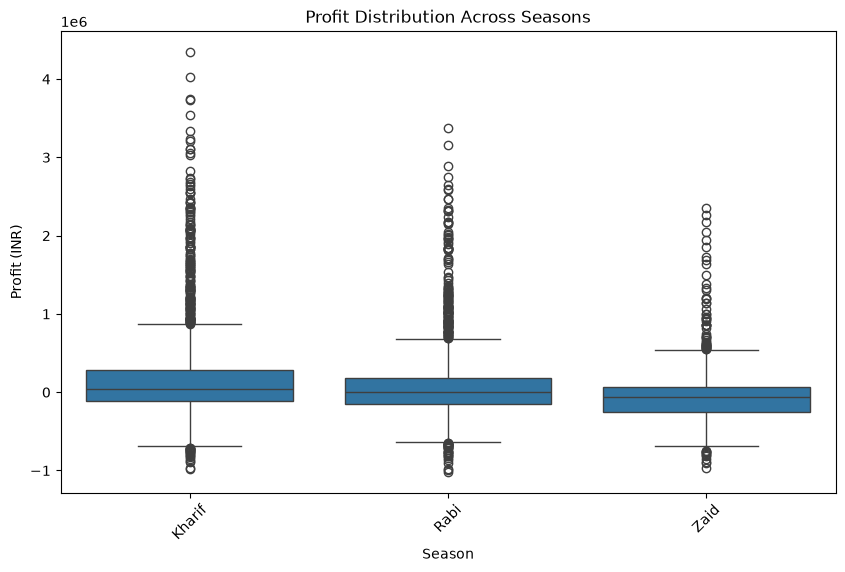

In [137]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.xticks(rotation=45)

plt.show()

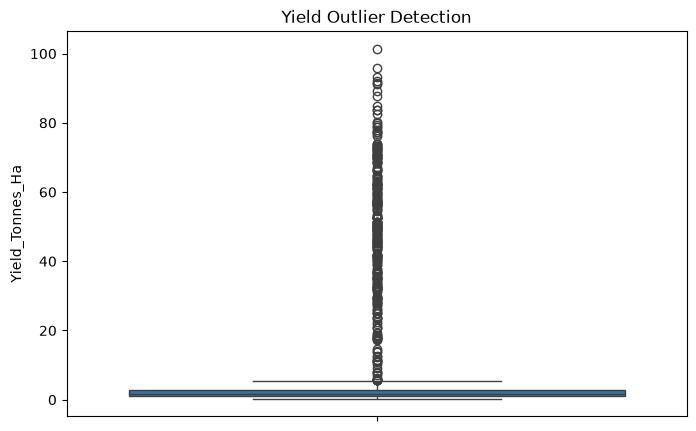

In [139]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Yield_Tonnes_Ha"]
)

plt.title("Yield Outlier Detection")

plt.show()

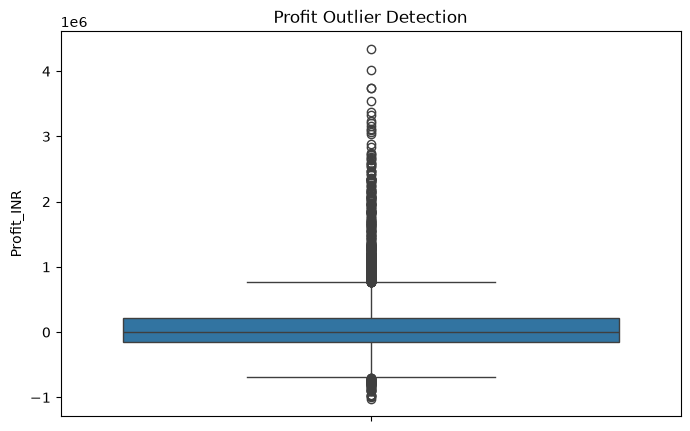

In [142]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Profit_INR"]
)

plt.title("Profit Outlier Detection")

plt.show()

In [144]:
season_groups = [
    group["Yield_Tonnes_Ha"].values
    for name, group in df.groupby("Season")
]

anova_result = stats.f_oneway(*season_groups)

anova_result

F_onewayResult(statistic=np.float64(1.54388045424883), pvalue=np.float64(0.21367813841845038))

In [147]:
if anova_result.pvalue < 0.05:
    print("There is a statistically significant difference in yield across seasons.")
else:
    print("There is no statistically significant difference in yield across seasons.")

There is no statistically significant difference in yield across seasons.


In [150]:
performance = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

performance

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,
Kharif,5.63,46.31,178914.65,5.89,54.47
Rabi,5.04,41.49,87689.47,5.19,40.48
Zaid,4.64,38.89,-24804.82,4.41,38.22


In [168]:
disease_season = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

disease_season

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

In [169]:
from sklearn.preprocessing import MinMaxScaler

score_columns = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]

season_score = df.groupby("Season")[score_columns].mean()

scaler = MinMaxScaler()

normalized = pd.DataFrame(
    scaler.fit_transform(season_score),
    columns=score_columns,
    index=season_score.index
)

normalized["Performance_Score"] = (
    normalized["Yield_Tonnes_Ha"] * 0.30 +
    normalized["Production_Tonnes"] * 0.20 +
    normalized["Profit_INR"] * 0.30 +
    normalized["Water_Efficiency_t_per_1000m3"] * 0.20
)

normalized.sort_values(
    "Performance_Score",
    ascending=False
)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Performance_Score
Season,,,,,
Kharif,1.000000,1.000000,1.000000,1.000000,1.000000
Rabi,0.403243,0.350245,0.552202,0.522715,0.461226
Zaid,0.000000,0.000000,0.000000,0.000000,0.000000


In [170]:
final = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Usage=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

final

,Average_Yield,Average_Production,Average_Profit,Average_Water_Usage,Water_Efficiency,Disease_Risk
Season,,,,,,
Kharif,5.63,46.31,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,-24804.82,6419.89,4.41,38.22


In [172]:
best_yield_season = s_yield.idxmax()
worst_yield_season = s_yield.idxmin()

best_profit_season = s_profit.idxmax()
worst_profit_season = s_profit.idxmin()

best_water_season = water_eff.idxmax()
highest_risk_season = disease_season.idxmax()

print("Best Yield Season:", best_yield_season)
print("Lowest Yield Season:", worst_yield_season)

print("Most Profitable Season:", best_profit_season)
print("Least Profitable Season:", worst_profit_season)

print("Most Water-Efficient Season:", best_water_season)
print("Highest Disease/Pest Risk Season:", highest_risk_season)

Best Yield Season: Kharif
Lowest Yield Season: Zaid
Most Profitable Season: Kharif
Least Profitable Season: Zaid
Most Water-Efficient Season: Kharif
Highest Disease/Pest Risk Season: Kharif
